### Harder variant — two touching squares ###

Solving the mixed-form Darcy flow on the unit square $[-1,1]^2$:

$$\begin{align*}
    -k \nabla u &= v\\
    \nabla \cdot v &= 0 \\
    u &= g_D \qquad             &\text{on } \Gamma_D \\
    v &= h \qquad &\text{on } \Gamma_N,
\end{align*}$$

with piecewise-constant permeability defined over **three regions** — two inner squares that **touch along the segment** $x=0,\,|y|\le 0.4$ and an exterior background:

$$k(x,y) = \begin{cases}
    1  & -0.4 \le x \le 0,\; |y| \le 0.4 \quad (\text{left square}) \\
    10 & 0 \le x \le 0.4,\; |y| \le 0.4 \quad (\text{right square}) \\
    3  & \text{otherwise}
\end{cases}$$

The large permeability contrast between the two inner squares ($k_L/k_R = 1/10$), together with the shared edge and four non-smooth corners, makes this a significantly harder test than either the circular or single-square variants.  
Two separate POU classifiers are trained — one per inner region.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import copy
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau
from skimage import measure

sys.path.append('../..')

from src import train, utils
from src.calculus import L2_norm
import src.data.cube_domain as cb
import src.models.expert_chars as ec
import src.models.mlp_model as mm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [1.0, 1.0]

SAVE_DIR = './darcy_learned_pou_sq'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'Using device: {device}')

Using device: cuda


In [4]:
# ── PDE / boundary-condition helpers ─────────────────────────────────────────
#
# Geometry: two inner squares that share the edge x=0, |y| ≤ 0.4
#   Region 1 (left  square): -0.4 ≤ x ≤ 0,   |y| ≤ 0.4  →  k = 1
#   Region 2 (right square):  0   ≤ x ≤ 0.4,  |y| ≤ 0.4  →  k = 10
#   Region 3 (exterior):      everything else              →  k = 3

def _in_region1(x: torch.Tensor) -> torch.Tensor:
    """Boolean mask: left inner square."""
    return (x[:, 0] >= -0.4) & (x[:, 0] <= 0.0) & (x[:, 1].abs() <= 0.4)

def _in_region2(x: torch.Tensor) -> torch.Tensor:
    """Boolean mask: right inner square."""
    return (x[:, 0] >= 0.0) & (x[:, 0] <= 0.4) & (x[:, 1].abs() <= 0.4)


def k(x: torch.Tensor) -> torch.Tensor:
    r1 = _in_region1(x)
    r2 = _in_region2(x)
    vals = torch.full((x.shape[0],), 3.0, device=x.device)
    vals = torch.where(r1, torch.tensor(1.0,  device=x.device), vals)
    vals = torch.where(r2, torch.tensor(10.0, device=x.device), vals)
    return vals.unsqueeze(1)


# True binary indicators (used for POU error visualisation)
def chi_1(x: torch.Tensor) -> torch.Tensor:
    """Indicator of region 1 (left square, k=1)."""
    return _in_region1(x).float().unsqueeze(1)

def chi_2(x: torch.Tensor) -> torch.Tensor:
    """Indicator of region 2 (right square, k=10)."""
    return _in_region2(x).float().unsqueeze(1)


# ── Boundary conditions ───────────────────────────────────────────────────────

def g_D(x: torch.Tensor) -> torch.Tensor:
    """Dirichlet BC: u = 0.5*(x+1), linear ramp left→right."""
    return 0.5 * (x[:, 0:1] + 1)

def u_0(x: torch.Tensor) -> torch.Tensor:
    """Hard-BC mask for u: vanishes on x = ±1."""
    return 1 - x[:, 0:1] ** 2

def v_0(x: torch.Tensor) -> torch.Tensor:
    """Hard-BC mask for v: v_y vanishes on y = ±1, v_x free."""
    shape = 1 - x[:, 1:2] ** 2
    ones  = torch.ones(x.shape[0], 1, device=x.device)
    return torch.cat([ones, shape], dim=1)

def h(x: torch.Tensor) -> torch.Tensor:
    """Neumann data on Γ_N."""
    return torch.cat([torch.zeros_like(x[:, 0:1]), x[:, 1:2]], dim=1)

In [5]:
# Collocation domain — 30 000 Latin-hypercube interior points (same as original)
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=30_000,
    N_sides=[(0, 0), (0, 0)],
    int_sampling='Latin',
    device=device,
)
domain = cb.CubeDomain(domain_ctx)
print(f'Interior points: {domain.interior.shape}')

Interior points: torch.Size([30000, 2])


## Stage 1 — Learning the Partition of Unity (POU)

One classifier MLP is trained **per inner region**:

| Model | Target region | Target $k$ | Loss |
|---|---|---|---|
| `model_char_1` | left square | $k=1$ | $\mathbb{E}[(u_\theta-\mathbf{1}_{k=1})^2]$ |
| `model_char_2` | right square | $k=10$ | $\mathbb{E}[(u_\theta-\mathbf{1}_{k=10})^2]$ |

The exterior region is the implicit residual $1 - \chi_1 - \chi_2$.

Architecture (both models): MLP $2 \to [64,64,64,64,64] \to 1$, ReLU last activation.  
Training: 60 000 Adam (lr $10^{-4}$) + 1 000 L-BFGS steps each.

In [6]:
# ── POU classification loss ────────────────────────────────────────────────
# Given a target k_value, train the model to output 1 inside that region
# and 0 everywhere else.

def loss_char_for_val(k_value):
    def loss_char(model, domain):
        x   = domain.interior.requires_grad_(True)
        kv  = k(x)
        u   = model(x)
        target = (kv == k_value).float()       # 1 in region, 0 outside
        return [torch.mean((u - target) ** 2)]
    return loss_char


# ── Shared architecture context ────────────────────────────────────────────
def make_char_ctx():
    return mm.ModelContext(
        input_dim=2,
        output_dim=1,
        layer=[64, 64, 64, 64, 64],
        last_layer_activation='relu',
        l_bounds=L_BOUNDS,
        u_bounds=U_BOUNDS,
    )


# model_char_1: detects left square  (k = 1)
model_char_1 = mm.MLPModel(make_char_ctx()).to(device=device)
char_optim_1 = torch.optim.Adam(model_char_1.parameters(), lr=1e-4)

# model_char_2: detects right square (k = 10)
model_char_2 = mm.MLPModel(make_char_ctx()).to(device=device)
char_optim_2 = torch.optim.Adam(model_char_2.parameters(), lr=1e-4)

print('POU models created — model_char_1 (k=1) and model_char_2 (k=10)')

POU models created — model_char_1 (k=1) and model_char_2 (k=10)


In [7]:
# ── Train model_char_1  (left square, k=1) ────────────────────────────────

train_ctx_1 = train.TrainingContext(
    model=model_char_1,
    domain=domain,
    optimizer=char_optim_1,
    loss_fn=loss_char_for_val(k_value=1.0),
    epochs=60_000,
    monitor_gradient=True,
    monitor_lr=True,
)

loss_char_hist_1, _ = train.train_switch_to_lbfgs(
    train_ctx_1, lbfgs_lr=0.1, epochs_with_lbfgs=1_000
)

Loss at epoch 1 is: 0.09952472150325775. Total gradient norm: 0.4198023151354174 Current learing rate: 0.0001 
Loss at epoch 100 is: 0.06945501267910004. Total gradient norm: 0.013232668752243194 Current learing rate: 0.0001 
Loss at epoch 200 is: 0.05410786718130112. Total gradient norm: 0.034744659919200206 Current learing rate: 0.0001 
Loss at epoch 300 is: 0.03053930774331093. Total gradient norm: 0.028117877100251043 Current learing rate: 0.0001 
Loss at epoch 400 is: 0.01877649687230587. Total gradient norm: 0.013160191083614037 Current learing rate: 0.0001 
Loss at epoch 500 is: 0.01564973033964634. Total gradient norm: 0.006685893757849433 Current learing rate: 0.0001 
Loss at epoch 600 is: 0.014408652670681477. Total gradient norm: 0.00721538668420036 Current learing rate: 0.0001 
Loss at epoch 700 is: 0.012652229517698288. Total gradient norm: 0.0068949560465357525 Current learing rate: 0.0001 
Loss at epoch 800 is: 0.011436812579631805. Total gradient norm: 0.005839540585137

In [8]:
# ── Train model_char_2  (right square, k=10) ──────────────────────────────

train_ctx_2 = train.TrainingContext(
    model=model_char_2,
    domain=domain,
    optimizer=char_optim_2,
    loss_fn=loss_char_for_val(k_value=10.0),
    epochs=60_000,
    monitor_gradient=True,
    monitor_lr=True,
)

loss_char_hist_2, _ = train.train_switch_to_lbfgs(
    train_ctx_2, lbfgs_lr=0.1, epochs_with_lbfgs=1_000
)

Loss at epoch 1 is: 0.09827452898025513. Total gradient norm: 0.4079691079073715 Current learing rate: 0.0001 
Loss at epoch 100 is: 0.06953997164964676. Total gradient norm: 0.017711085993571962 Current learing rate: 0.0001 
Loss at epoch 200 is: 0.051851749420166016. Total gradient norm: 0.03588121101128355 Current learing rate: 0.0001 
Loss at epoch 300 is: 0.025353357195854187. Total gradient norm: 0.02682862348246556 Current learing rate: 0.0001 
Loss at epoch 400 is: 0.017087290063500404. Total gradient norm: 0.009875985754025386 Current learing rate: 0.0001 
Loss at epoch 500 is: 0.014884826727211475. Total gradient norm: 0.008233298826868796 Current learing rate: 0.0001 
Loss at epoch 600 is: 0.013108137995004654. Total gradient norm: 0.006338629475892215 Current learing rate: 0.0001 
Loss at epoch 700 is: 0.011671768501400948. Total gradient norm: 0.006222398143705229 Current learing rate: 0.0001 
Loss at epoch 800 is: 0.010559624992311. Total gradient norm: 0.0066317277082710

In [9]:
model_char_1.requires_grad_(False)
model_char_2.requires_grad_(False)
cutoff = 0.5

def chi_learned_1(x: torch.Tensor) -> torch.Tensor:
    """Learned indicator for the left square (k=1)."""
    return (model_char_1(x) >= cutoff).float()

def chi_learned_2(x: torch.Tensor) -> torch.Tensor:
    """Learned indicator for the right square (k=10)."""
    return (model_char_2(x) >= cutoff).float()

def chi_learned_ext(x: torch.Tensor) -> torch.Tensor:
    """Implicit exterior region: 1 - chi_1 - chi_2."""
    return torch.clamp(1.0 - chi_learned_1(x) - chi_learned_2(x), 0.0, 1.0)

/home/berva/miniconda3/envs/torch/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/libtorch_1745854776362/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


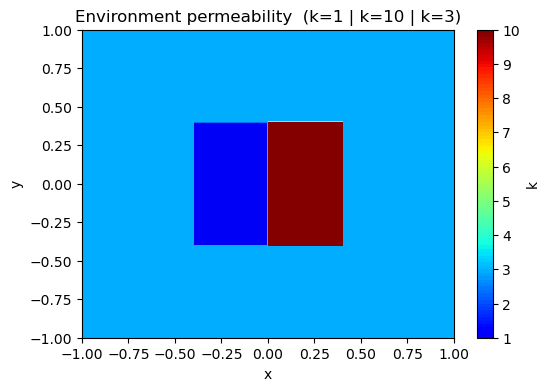

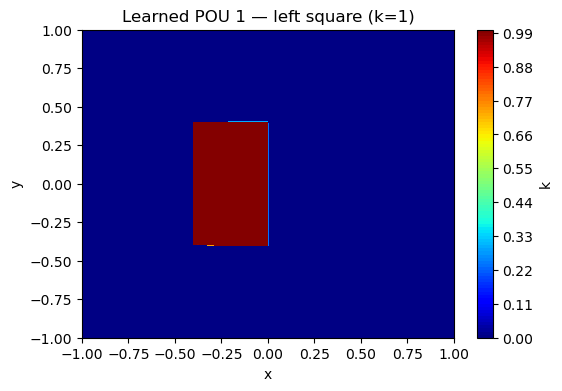

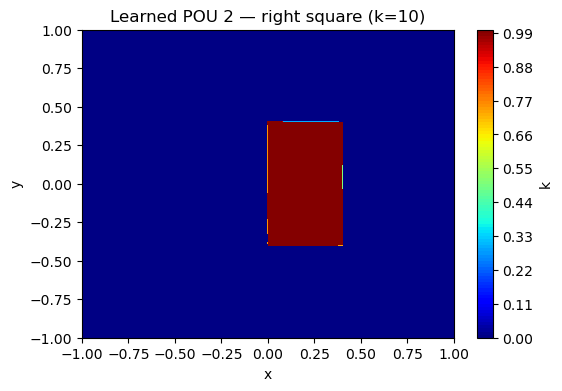

In [10]:
# ── Visualise permeability field + both learned POUs ──────────────────────────

plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=['Environment permeability  (k=1 | k=10 | k=3)'],
    function_names=['k'],
    colour_map='jet',
    vmin=0,
    vmax=10,
    device=device,
    N=1000,
    save_img=True,
)

plot_ctx.save_path = f'{SAVE_DIR}/environment_permeability.png'
utils.plot_function_on_2d_cube([k], plot_ctx)

plot_ctx.vmin, plot_ctx.vmax = 0, 1

plot_ctx.save_path = f'{SAVE_DIR}/learned_pou_1.png'
plot_ctx.titles    = ['Learned POU 1 — left square (k=1)']
utils.plot_function_on_2d_cube([chi_learned_1], plot_ctx)

plot_ctx.save_path = f'{SAVE_DIR}/learned_pou_2.png'
plot_ctx.titles    = ['Learned POU 2 — right square (k=10)']
utils.plot_function_on_2d_cube([chi_learned_2], plot_ctx)

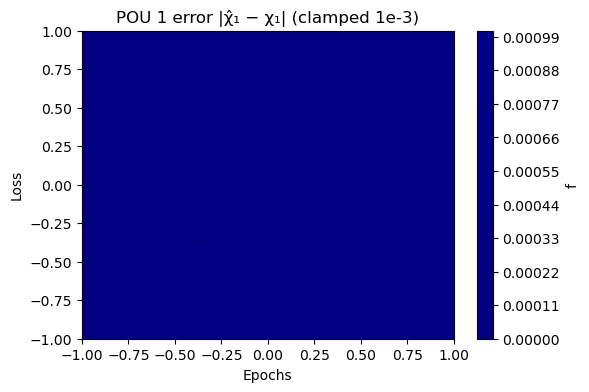

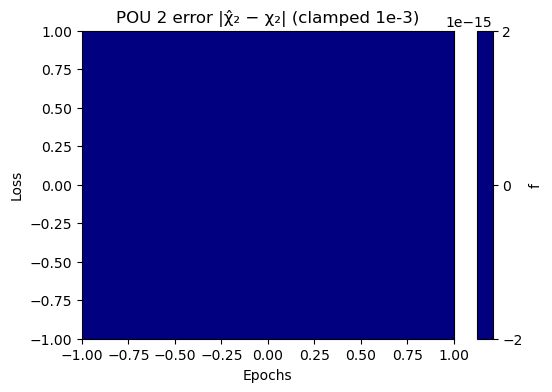

In [46]:
# Pointwise POU errors — clipped to [0, 1e-4] to see fine structure
plot_ctx.vmin, plot_ctx.vmax = 0.0, 1e-1

plot_ctx.save_path = f'{SAVE_DIR}/pou_error_1.png'
plot_ctx.titles    = ['POU 1 error |χ̂₁ − χ₁| (clamped 1e-3)']
utils.plot_function_on_2d_cube(
    [lambda x: torch.clamp(torch.abs(chi_learned_1(x) - chi_1(x)), 0.0, 0.001)],
    plot_ctx
)

plot_ctx.save_path = f'{SAVE_DIR}/pou_error_2.png'
plot_ctx.titles    = ['POU 2 error |χ̂₂ − χ₂| (clamped 1e-3)']
utils.plot_function_on_2d_cube(
    [lambda x: torch.clamp(torch.abs(chi_learned_2(x) - chi_2(x)), 0.0, 1e-3)],
    plot_ctx
)

## Stage 2 — Interface Contour Extraction and Splitting

For each learned POU model we first extract its full level-set contour at
value 0.5 using `skimage.measure.find_contours` on a $1300\times 1300$ grid.
The two raw contours are then **split** into three semantically distinct
interface sub-curves by checking whether each point lies within
`SPLIT_TOL = 0.02` of the shared edge ($x=0$):

| Sub-curve | Source contour | Physical interface |
|---|---|---|
| `contour_sq_sq` | `contour_tensor_1` | square–square shared edge ($x\approx 0$, $|y|\le 0.4$) |
| `contour_left_bg` | `contour_tensor_1` | left square / exterior background |
| `contour_right_bg` | `contour_tensor_2` | right square / exterior background |

Normal vectors are then computed independently for each sub-curve using the
classifier whose gradient is meaningful on that interface:

| Normal tensor | Classifier | Outward direction |
|---|---|---|
| `norm_sq_sq` | `model_char_1` | away from left square (into right square) |
| `norm_left_bg` | `model_char_1` | away from left square (into background) |
| `norm_right_bg` | `model_char_2` | away from right square (into background) |

In [21]:
# ── Extract level-set contours for both POU models ─────────────────────────

N_grid = 1400

x_lin = torch.linspace(-1, 1, N_grid)
y_lin = torch.linspace(-1, 1, N_grid)
X_mg, Y_mg = torch.meshgrid(x_lin, y_lin, indexing='ij')

inp  = torch.column_stack((X_mg.reshape(-1), Y_mg.reshape(-1))).to(device)
x_np = torch.linspace(-1, 1, N_grid).numpy()
y_np = torch.linspace(-1, 1, N_grid).numpy()


def extract_contour(model, inp, N_grid, x_np, y_np, cutoff):
    """Return the largest level-set contour of `model` at `cutoff` as a
    float32 tensor of shape (M, 2) in physical coordinates."""
    outp = model(inp).detach().cpu().numpy().reshape(N_grid, N_grid)
    raw  = measure.find_contours(outp, cutoff)
    if not raw:
        raise RuntimeError('No contour found — check model training.')
    c = max(raw, key=lambda c: len(c))
    cx = np.interp(c[:, 0], np.arange(N_grid), x_np)
    cy = np.interp(c[:, 1], np.arange(N_grid), y_np)
    return torch.tensor(np.column_stack([cx, cy]), dtype=torch.float32, device=device)


contour_tensor_1 = extract_contour(model_char_1, inp, N_grid, x_np, y_np, cutoff)
contour_tensor_2 = extract_contour(model_char_2, inp, N_grid, x_np, y_np, cutoff)

print(f'Contour 1 (left  square, k=1 ): {contour_tensor_1.shape[0]} points')
print(f'Contour 2 (right square, k=10): {contour_tensor_2.shape[0]} points')

Contour 1 (left  square, k=1 ): 1685 points
Contour 2 (right square, k=10): 1695 points


In [22]:
# ── Split each raw contour into per-interface sub-curves ───────────────────
#
# Physical interfaces:
#   sq_sq    : x ≈ 0, |y| ≤ 0.4  — shared edge between the two inner squares
#   left_bg  : rest of contour_1  — left square / exterior background
#   right_bg : rest of contour_2  — right square / exterior background
#
# After splitting, points within `CORNER_RADIUS` of any known geometry corner
# are discarded so that the ambiguous corner regions carry no normal vectors.

SPLIT_TOL    = 0.01   # points with |x| < SPLIT_TOL are assigned to sq_sq
CORNER_RADIUS = 0.01  # physical distance around each corner to exclude

# All six corners of the two-square geometry
CORNERS = np.array([
    [-0.4, -0.4], [-0.4,  0.4],   # left-square outer corners
    [ 0.0, -0.4], [ 0.0,  0.4],   # shared edge endpoints (inner corners)
    [ 0.4, -0.4], [ 0.4,  0.4],   # right-square outer corners
], dtype=np.float32)


def _label_sq_sq(pts: np.ndarray, tol: float = SPLIT_TOL) -> np.ndarray:
    """Return boolean array: True where a point belongs to sq-sq interface."""
    return (np.abs(pts[:, 0]) < tol) & (np.abs(pts[:, 1]) <= 0.4)


def _trim_near_corners(pts_tensor: torch.Tensor,
                       corners: np.ndarray = CORNERS,
                       radius: float = CORNER_RADIUS) -> torch.Tensor:
    """Remove points that lie within `radius` of any geometry corner."""
    if len(pts_tensor) == 0:
        return pts_tensor
    pts = pts_tensor.cpu().numpy()                      # (M, 2)
    dists = np.linalg.norm(                             # (M, C)
        pts[:, None, :] - corners[None, :, :], axis=2
    )
    keep = dists.min(axis=1) >= radius                  # (M,)
    return pts_tensor[torch.tensor(keep, device=pts_tensor.device)]


def _split_by_label(pts_tensor: torch.Tensor, mask: np.ndarray, dev):
    """
    Given an ordered contour `pts_tensor` (M, 2) and a boolean `mask` (M,),
    return two tensors: points where mask is True and points where it is False.
    Each consists of all consecutive same-labeled runs concatenated together.
    """
    pts = pts_tensor.cpu().numpy()
    true_segs, false_segs = [], []
    n = len(mask)
    i = 0
    while i < n:
        j = i
        while j < n and mask[j] == mask[i]:
            j += 1
        seg = pts[i:j]
        (true_segs if mask[i] else false_segs).append(seg)
        i = j
    to_tensor = lambda segs: (
        torch.tensor(np.concatenate(segs, axis=0), dtype=torch.float32, device=dev)
        if segs else torch.empty(0, 2, device=dev)
    )
    return to_tensor(true_segs), to_tensor(false_segs)


mask_1 = _label_sq_sq(contour_tensor_1.cpu().numpy())
mask_2 = _label_sq_sq(contour_tensor_2.cpu().numpy())

contour_sq_sq_raw,   contour_left_bg_raw  = _split_by_label(contour_tensor_1, mask_1, device)
contour_sq_sq_2_raw, contour_right_bg_raw = _split_by_label(contour_tensor_2, mask_2, device)

# Remove points near corners from every sub-curve
contour_sq_sq    = _trim_near_corners(contour_sq_sq_raw)
contour_sq_sq_2  = _trim_near_corners(contour_sq_sq_2_raw)
contour_left_bg  = _trim_near_corners(contour_left_bg_raw)
contour_right_bg = _trim_near_corners(contour_right_bg_raw)

print(f'sq-sq interface            : {len(contour_sq_sq):>5} points  (from model_char_1)')
print(f'sq-sq interface (model 2)  : {len(contour_sq_sq_2):>5} points  (from model_char_2, cross-check)')
print(f'left-square / background   : {len(contour_left_bg):>5} points')
print(f'right-square / background  : {len(contour_right_bg):>5} points')

sq-sq interface            :   550 points  (from model_char_1)
sq-sq interface (model 2)  :   550 points  (from model_char_2, cross-check)
left-square / background   :  1088 points
right-square / background  :  1086 points


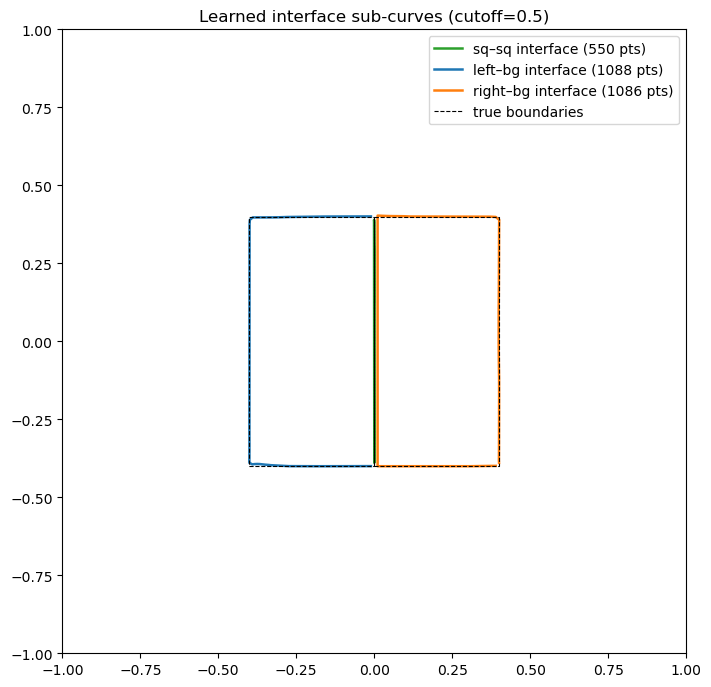

In [23]:
# ── Plot the three learned interface sub-curves ────────────────────────────
#
#   green  : sq-sq shared edge  (x=0, |y| ≤ 0.4)
#   blue   : left square / background
#   orange : right square / background

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

for ct, color, label in [
    (contour_sq_sq,    'tab:green',  f'sq–sq interface ({len(contour_sq_sq)} pts)'),
    (contour_left_bg,  'tab:blue',   f'left–bg interface ({len(contour_left_bg)} pts)'),
    (contour_right_bg, 'tab:orange', f'right–bg interface ({len(contour_right_bg)} pts)'),
]:
    if len(ct) == 0:
        continue
    p = ct.cpu().numpy()
    ax.plot(p[:, 0], p[:, 1], linewidth=1.8, color=color, label=label)

# True boundaries for comparison
ax.plot([-0.4, 0.0, 0.0, -0.4, -0.4], [-0.4, -0.4, 0.4, 0.4, -0.4],
        'k--', linewidth=0.8, label='true boundaries')
ax.plot([ 0.0, 0.4, 0.4,  0.0,  0.0], [-0.4, -0.4, 0.4, 0.4, -0.4],
        'k--', linewidth=0.8)

ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect('equal')
ax.set_title(f'Learned interface sub-curves (cutoff={cutoff})')
ax.legend()
plt.savefig(f'{SAVE_DIR}/pou_interface_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ── Outward unit normals via autodiff — one set per interface sub-curve ────
#
# Convention: normals point *away from* the region of the classifier used.
#
#   contour_sq_sq    → model_char_1 → normal points away from left square
#                      (i.e. into the right square / across the shared edge)
#   contour_left_bg  → model_char_1 → normal points away from left square
#                      (i.e. into the exterior background)
#   contour_right_bg → model_char_2 → normal points away from right square
#                      (i.e. into the exterior background)

def compute_normals(model, contour_tensor):
    """Return unit outward normals (M, 2) for every point in contour_tensor.
    n = -∇model / ‖∇model‖  (gradient points inward → negate for outward)."""
    if len(contour_tensor) == 0:
        return torch.empty(0, 2, device=contour_tensor.device)
    model.requires_grad_(True)
    ct  = contour_tensor.detach().requires_grad_(True)
    out = model(ct)
    g   = grad(out, ct, torch.ones_like(out))[0]          # (M, 2)
    nrm = -g / torch.norm(g, dim=1, p=2, keepdim=True)
    model.requires_grad_(False)
    return nrm.detach()

norm_sq_sq    = compute_normals(model_char_1, contour_sq_sq)
norm_left_bg  = compute_normals(model_char_1, contour_left_bg)
norm_right_bg = compute_normals(model_char_2, contour_right_bg)

print(f'norm_sq_sq    (model_char_1): {norm_sq_sq.shape}')
print(f'norm_right_bg (model_char_2): {norm_right_bg.shape}')
print(f'norm_left_bg  (model_char_1): {norm_left_bg.shape}')

norm_sq_sq    (model_char_1): torch.Size([550, 2])
norm_right_bg (model_char_2): torch.Size([1086, 2])
norm_left_bg  (model_char_1): torch.Size([1088, 2])


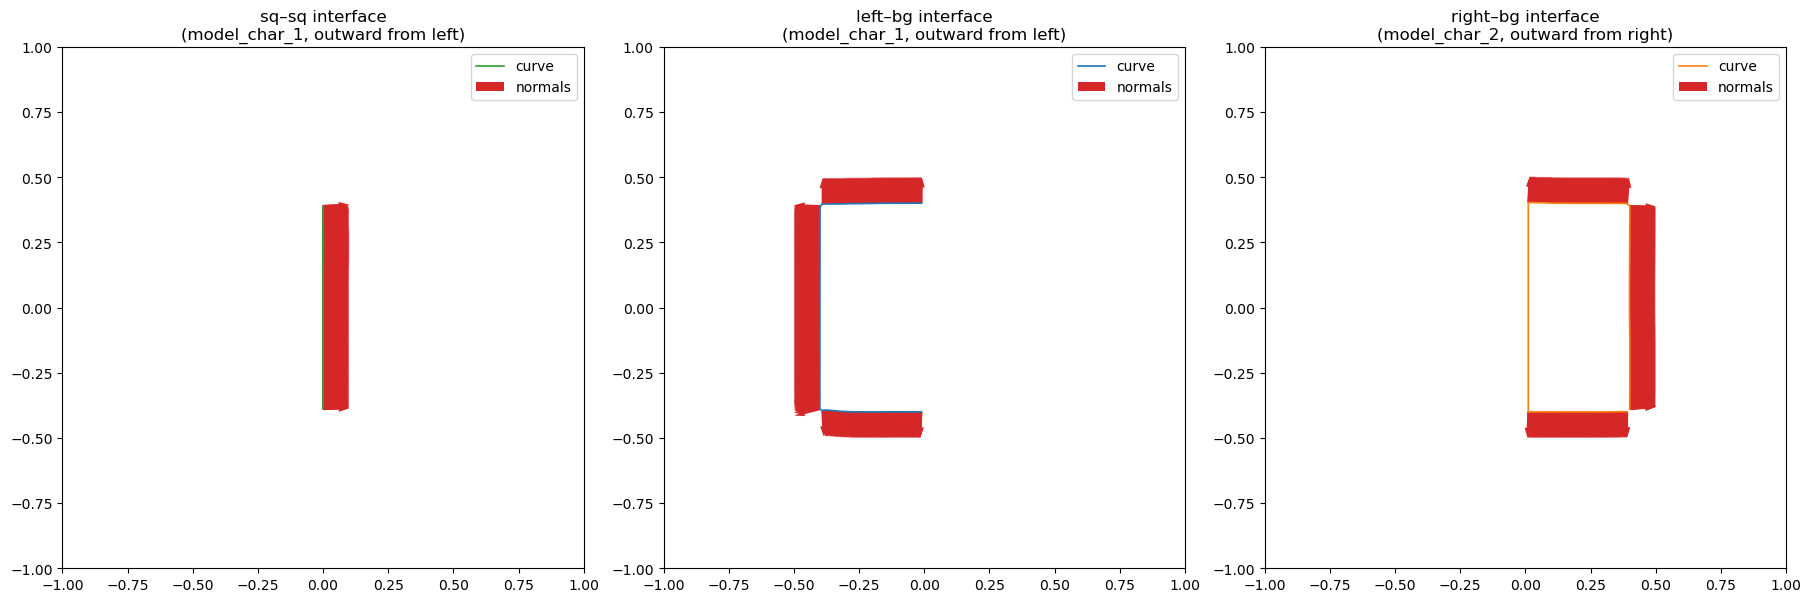

In [25]:
# ── Visualise outward normals on all three interface sub-curves ─────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for ax, ct, nrm, color, title in [
    (axes[0], contour_sq_sq,    norm_sq_sq,
     'tab:green',  'sq–sq interface\n(model_char_1, outward from left)'),
    (axes[1], contour_left_bg,  norm_left_bg,
     'tab:blue',   'left–bg interface\n(model_char_1, outward from left)'),
    (axes[2], contour_right_bg, norm_right_bg,
     'tab:orange', 'right–bg interface\n(model_char_2, outward from right)'),
]:
    if len(ct) == 0:
        ax.set_title(title + '\n(no points)'); continue

    pts  = ct.cpu().numpy()
    nrm_ = nrm.cpu().numpy()
    step = max(1, len(pts) // 2000)

    ax.plot(pts[:, 0], pts[:, 1], color=color, linewidth=1.2, label='curve')
    ax.quiver(pts[::step, 0], pts[::step, 1],
        nrm_[::step, 0], nrm_[::step, 1],
        color='tab:red', scale=20, width=0.004, label='normals')
    
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')

    ax.set_title(title)
    ax.legend()

plt.savefig(f'{SAVE_DIR}/normals_per_interface.png', dpi=150, bbox_inches='tight')


## Stage 3 — Main Model Training

Two sub-networks combined into a `MultiModel`:

| Sub-model | Output | Architecture | Hard BC |
|-----------|--------|--------------|---------|
| `model_u_exp` | scalar potential $u$ | MLP $2\to[32,32,32]\to 1$ | Dirichlet $g_D$ via `u_0` |
| `model_v_exp` | flux $v$ (3 experts) | 3 × MLP $2\to[16,16,16]\to 2$ | Neumann $h$ via `v_0` |

The three experts of `model_v_exp` are gated by the **frozen** learned POU classifiers so that each expert specialises on one permeability region:

| Expert | Gate | Region | $k$ |
|--------|------|--------|-----|
| 0 | `chi_learned_1` | left square | 1 |
| 1 | `chi_learned_2` | right square | 10 |
| 2 | `chi_learned_ext` | exterior background | 3 |

**Loss terms:**

1. $\|k\,\nabla u + v\|^2$ — equation residual ($-k\nabla u = v$)
2. $\|\nabla\cdot v\|^2$ — solenoidal constraint
3. Flux continuity across each of the **three** learned interface sub-curves:
   - sq–sq ($x\approx 0$, $|y|\le 0.4$): $\langle v_0,n\rangle = \langle v_1,n\rangle$
   - left–bg: $\langle v_0,n\rangle = \langle v_2,n\rangle$
   - right–bg: $\langle v_1,n\rangle = \langle v_2,n\rangle$

Training: 120 000 Adam (lr $5\times10^{-4}$, ReduceLROnPlateau factor 0.75, patience 2 000) + 1 000 L-BFGS


In [26]:
# ── PDE residual helper: returns (res_1, res_2) ────────────────────────────
#   res_1 = k * grad(u) + v       (N, 2)
#   res_2 = div(v)                 (N,)

def res(u: torch.Tensor, v: torch.Tensor, pde_in: torch.Tensor):
    grad_u = grad(u, pde_in, torch.ones_like(u), create_graph=True)[0]  # (N,2)

    res_1 = k(pde_in) * grad_u + v                                       # (N,2)

    v_1_x = grad(v[:, 0], pde_in, torch.ones_like(v[:, 0]),
                 create_graph=True)[0][:, 0]
    v_2_y = grad(v[:, 1], pde_in, torch.ones_like(v[:, 1]),
                 create_graph=True)[0][:, 1]
    res_2 = v_1_x + v_2_y                                                # (N,)

    return res_1, res_2

In [27]:
# ── Model construction ─────────────────────────────────────────────────────
# The three POU classifiers are used *frozen* (gradients disabled in Stage 1).
# Expert 0 → left square  (k=1,  gate: chi_learned_1)
# Expert 1 → right square (k=10, gate: chi_learned_2)
# Expert 2 → exterior     (k=3,  gate: chi_learned_ext)

model_ctx_u = mm.ModelContext(
    input_dim=2,
    output_dim=1,
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    layer=[32, 32, 32],
    hard_enforce=True,
    constraint_functions=(g_D, u_0),
)

model_ctx_v_exp = ec.PerCharCtx(
    input_dim=2,
    output_dim=2,
    char_functions=[chi_learned_1, chi_learned_2, chi_learned_ext],
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    hidden_layers_per_output=[[16, 16, 16], [16, 16, 16], [16, 16, 16]],
    hard_enforce=True,
    constraint_functions=(h, v_0),
)

model_u_exp        = mm.MLPModel(model_ctx_u).to(device)
model_v_exp        = ec.PerCharModel(model_ctx_v_exp).to(device)
model_combined_exp = ec.MultiModel(model_u_exp, model_v_exp).to(device)

optim_combine_exp  = torch.optim.Adam(model_combined_exp.parameters(), lr=5e-4)
sched_combine_exp  = ReduceLROnPlateau(optim_combine_exp, factor=0.75, patience=2_000)

model_init_exp     = copy.deepcopy(model_combined_exp)
print('Architecture ready (3 experts); initial snapshot saved.')


Architecture ready (3 experts); initial snapshot saved.


In [ ]:
# ── Training loss with five components ─────────────────────────────────────
#
#   loss_1  — equation residual ||k ∇u + v||²
#   loss_2  — divergence residual ||∇·v||²
#   cont_sq_sq   — flux continuity: expert 0 vs expert 1  (sq–sq interface)
#   cont_left_bg — flux continuity: expert 0 vs expert 2  (left–bg interface)
#   cont_right_bg— flux continuity: expert 1 vs expert 2  (right–bg interface)

def loss_combined(model: torch.nn.Module, domain: cb.CubeDomain):
    pde_in  = domain.interior.requires_grad_(True)
    pde_out = model(pde_in)
    u = pde_out[:, 0]
    v = pde_out[:, 1:]

    res_1, res_2 = res(u, v, pde_in)
    res_sq = res_1[:, 0] ** 2 + res_1[:, 1] ** 2   # ||k grad u + v||²

    experts = model.models[1].experts   # list of 3 expert sub-networks

    # ── sq–sq interface: expert 0 (left, k=1) vs expert 1 (right, k=10) ──
    def _cont_loss(ct, nrm, exp_a, exp_b):
        if len(ct) == 0:
            return torch.tensor(0.0, device=pde_in.device)
        ct_d = ct.detach()
        va = exp_a(ct_d)
        vb = exp_b(ct_d)
        return torch.mean((torch.sum(va * nrm.detach(), dim=1)
                         - torch.sum(vb * nrm.detach(), dim=1)) ** 2)

    cont_sq_sq    = _cont_loss(contour_sq_sq,    norm_sq_sq,    experts[0], experts[1])
    cont_left_bg  = _cont_loss(contour_left_bg,  norm_left_bg,  experts[0], experts[2])
    cont_right_bg = _cont_loss(contour_right_bg, norm_right_bg, experts[1], experts[2])

    loss_1 = torch.mean(res_sq)        # equation residual
    loss_2 = torch.mean(res_2 ** 2)    # divergence residual

    return [loss_1, loss_2, cont_sq_sq, cont_left_bg, cont_right_bg]


In [29]:
# ── Train — Adam (120 000 epochs) then L-BFGS (1 000 steps) ───────────────

domain.ctx.N_int = 10_000      # reduce collocation points during main training

train_ctx = train.TrainingContext(
    model=model_combined_exp,
    domain=domain,
    optimizer=optim_combine_exp,
    loss_fn=loss_combined,
    epochs=120_000,
    monitor_gradient=True,
    monitor_lr=True,
)

loss_exp, loss_comps_exp = train.train_switch_to_lbfgs(
    train_ctx, lbfgs_lr=0.1, epochs_with_lbfgs=1_000
)

Loss at epoch 1 is: 6.374718189239502. Total gradient norm: nan Current learing rate: 0.0005 
Loss at epoch 100 is: 1.4107180833816528. Total gradient norm: 2.75004228618859 Current learing rate: 0.0005 
Loss at epoch 200 is: 0.7242276072502136. Total gradient norm: 0.5611301018929484 Current learing rate: 0.0005 
Loss at epoch 300 is: 0.5721196532249451. Total gradient norm: 0.5203477173405454 Current learing rate: 0.0005 
Loss at epoch 400 is: 0.4168788194656372. Total gradient norm: 0.3876592621529485 Current learing rate: 0.0005 
Loss at epoch 500 is: 0.34283068776130676. Total gradient norm: 0.38049636318036517 Current learing rate: 0.0005 
Loss at epoch 600 is: 0.32236552238464355. Total gradient norm: 0.19022412566243171 Current learing rate: 0.0005 
Loss at epoch 700 is: 0.30741310119628906. Total gradient norm: 0.2930891428790195 Current learing rate: 0.0005 
Loss at epoch 800 is: 0.3024701774120331. Total gradient norm: 0.12090497125936604 Current learing rate: 0.0005 
Loss a

## Results — Visualisation & Evaluation

Output plots follow the same schema as the circular-interface experiment:
1. **Training losses** (all five components over epochs)
2. **Model outputs** — $u$ prediction, $\nabla u$ field, $v$ vector field
3. **PDE residuals** — equation $\|k\nabla u + v\|$ and divergence $\|\nabla\cdot v\|$
4. **L2 errors vs. FEM reference** — pointwise error maps $|u_\text{pred}-u_\text{fem}|$ and $\|v_\text{pred}-v_\text{fem}\|$

The FEM reference is loaded from **`darcy_two_square_solution.h5`** produced by `darcy_two_square_fem.py`, which solves the same primal Darcy problem ($-\nabla\cdot(k\nabla u)=0$) on a 250×250 P1 mesh and exports the pressure $u$ and Darcy flux $v=-k\nabla u$ on a 100×100 sample grid.


/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/darcy/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


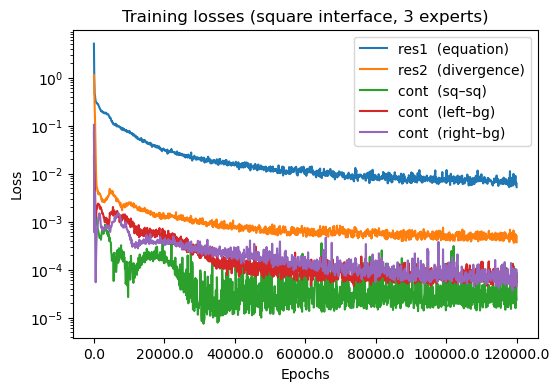

In [30]:
# ── Training loss curves ───────────────────────────────────────────────────

plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=['Training losses (square interface, 3 experts)'],
    function_names=['f'],
    colour_map='jet',
    vmin=None,
    vmax=None,
    device=device,
    N=200,
    save_img=True,
    y_label='Loss',
    x_label='Epochs',
)

plot_ctx.save_path = f'{SAVE_DIR}/model_exps_losses.png'
utils.plot_loss_values(
    {
        'res1  (equation)':       loss_comps_exp[0],
        'res2  (divergence)':     loss_comps_exp[1],
        'cont  (sq–sq)':          loss_comps_exp[2],
        'cont  (left–bg)':        loss_comps_exp[3],
        'cont  (right–bg)':       loss_comps_exp[4],
    },
    plot_ctx
)


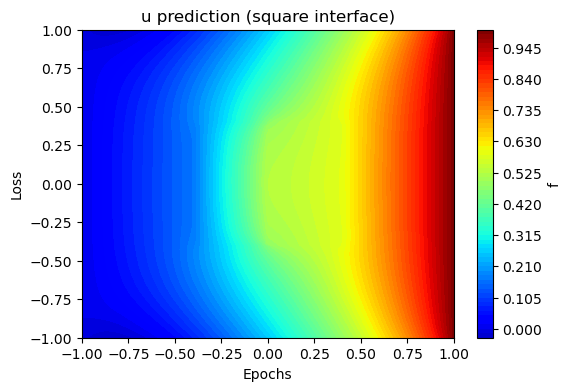

In [31]:
# ── u prediction ─────────────────────────────────────────────────────────

plot_ctx.vmin = -0.1
plot_ctx.vmax = 1.0
plot_ctx.titles    = ['u prediction (square interface)']
plot_ctx.save_path = f'{SAVE_DIR}/model_u_exp_pred.png'
utils.plot_function_on_2d_cube(
    [lambda x: model_combined_exp(x)[:, 0]], plot_ctx
)

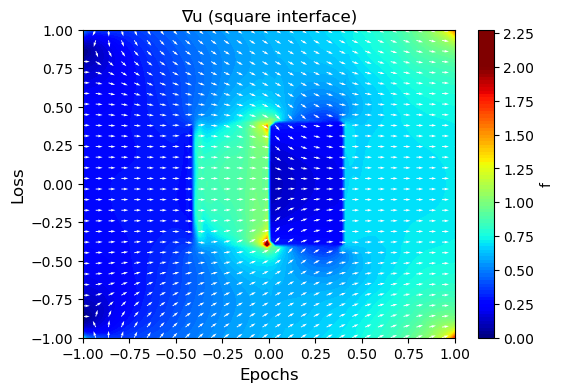

In [32]:
# ── grad u (vector field) ─────────────────────────────────────────────────

def heat_flow(x, model):
    x = x.requires_grad_(True)
    u = model(x)[:, 0]
    return grad(u, x, torch.ones_like(u))[0]

plot_ctx.vmin = 0.0
plot_ctx.vmax = 2.0
plot_ctx.titles    = ['∇u (square interface)']
plot_ctx.save_path = f'{SAVE_DIR}/model_u_exp_grad.png'
utils.plot_vector_field_2d(
    [lambda x: heat_flow(x, model_combined_exp)],
    plot_ctx, N=100, n_heigth=30, n_width=30
)

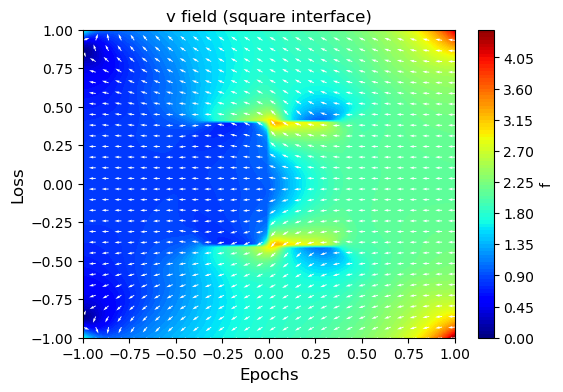

In [33]:
# ── v vector field ────────────────────────────────────────────────────────

plot_ctx.vmin = 0.0
plot_ctx.vmax = 4.5
plot_ctx.titles    = ['v field (square interface)']
plot_ctx.save_path = f'{SAVE_DIR}/model_v_exp.png'
utils.plot_vector_field_2d(
    [lambda x: model_combined_exp(x)[:, 1:]],
    plot_ctx, N=100, n_heigth=30, n_width=30
)

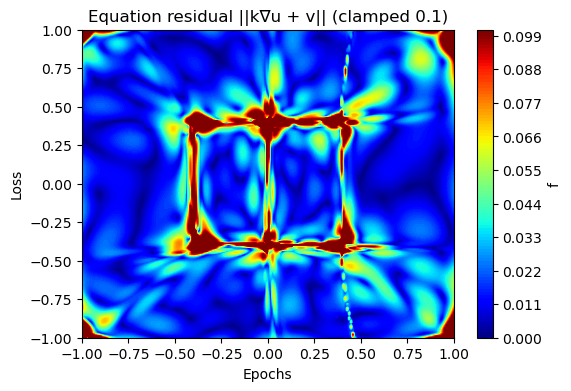

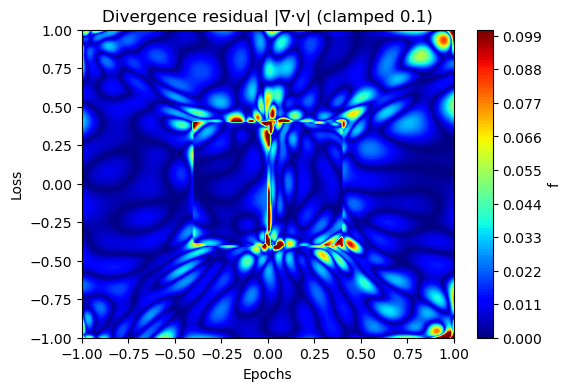

In [34]:
# ── PDE residuals — equation and divergence ───────────────────────────────

def res_div_helper(x, model):
    x = x.requires_grad_(True)
    out = model(x)
    u   = out[:, 0]
    v   = out[:, 1:]
    r1, r2 = res(u, v, x)
    return torch.norm(r1, p=2, dim=1), r2   # (N,), (N,)


plot_ctx.vmin = 0.0
plot_ctx.vmax = 0.1

plot_ctx.titles    = ['Equation residual ||k∇u + v|| (clamped 0.1)']
plot_ctx.save_path = f'{SAVE_DIR}/model_v_exp_equation.png'
utils.plot_function_on_2d_cube(
    [lambda x: torch.clamp(res_div_helper(x, model_combined_exp)[0].unsqueeze(1), 0.0, 0.1)],
    plot_ctx
)

plot_ctx.titles    = ['Divergence residual |∇·v| (clamped 0.1)']
plot_ctx.save_path = f'{SAVE_DIR}/model_v_exp_div.png'
utils.plot_function_on_2d_cube(
    [lambda x: torch.clamp(res_div_helper(x, model_combined_exp)[1].abs().unsqueeze(1), 0.0, 0.1)],
    plot_ctx
)

In [35]:
# ── Global L2 norms of PDE residuals ──────────────────────────────────────

zero_2d = lambda x: torch.zeros(x.shape[0], 2, device=x.device)
zero_1d = lambda x: torch.zeros(x.shape[0], 1, device=x.device)


def make_res1_fn(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        r1, _ = res(u, v, x)
        return r1
    return f


def make_res2_fn(model):
    def f(x):
        x = x.requires_grad_(True)
        out = model(x)
        u, v = out[:, 0], out[:, 1:]
        _, r2 = res(u, v, x)
        return r2.unsqueeze(1)
    return f


l2_r1 = L2_norm(make_res1_fn(model_combined_exp), zero_2d,
                input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS,
                device=str(device), n=50)
l2_r2 = L2_norm(make_res2_fn(model_combined_exp), zero_1d,
                input_dim=2, u_bounds=U_BOUNDS, l_bounds=L_BOUNDS,
                device=str(device), n=50)

print(f"{'Model':<20}  {'L2 ||res1||':>12}  {'L2 ||res2||':>12}")
print('-' * 48)
print(f"{'combined_exp':<20}  {l2_r1.item():>12.6e}  {l2_r2.item():>12.6e}")

Model                  L2 ||res1||   L2 ||res2||
------------------------------------------------
combined_exp          1.248808e-01  3.092180e-02


In [38]:
# ── L2 error vs FEM reference (darcy_two_square_solution.h5) ──────────────

with h5py.File('darcy_two_square_solution.h5', 'r') as f:
    xy_np    = f['samples/xy'][:]
    u_fem    = f['samples/u_interp'][:]
    v_fem_np = f['samples/flux_interp'][:]

xy_fem  = torch.tensor(xy_np,    dtype=torch.float32, device=device)
u_fem_t = torch.tensor(u_fem,    dtype=torch.float32, device=device)
v_fem_t = torch.tensor(v_fem_np, dtype=torch.float32, device=device)

u_true_norm  = torch.linalg.vector_norm(u_fem_t,           ord=2)
v_true_norm  = torch.linalg.vector_norm(v_fem_t.reshape(-1), ord=2)

model_combined_exp.eval()
with torch.no_grad():
    out    = model_combined_exp(xy_fem)
    u_pred = out[:, 0]
    v_pred = out[:, 1:]

    u_err    = (u_pred - u_fem_t).abs()
    u_l2     = torch.linalg.vector_norm(u_err, ord=2)
    u_rel_l2 = u_l2 / (u_true_norm + 1e-12)
    u_rmse   = torch.sqrt(torch.mean((u_pred - u_fem_t) ** 2))

    v_err_mag = torch.norm(v_pred - v_fem_t, dim=1, p=2)
    v_l2      = torch.linalg.vector_norm(v_err_mag,       ord=2)
    v_rel_l2  = v_l2 / (v_true_norm + 1e-12)
    v_rmse    = torch.sqrt(torch.mean((v_pred - v_fem_t) ** 2))

    vx_err    = (v_pred[:, 0] - v_fem_t[:, 0]).abs()
    vx_l2     = torch.linalg.vector_norm(vx_err, ord=2)
    vx_true_n = torch.linalg.vector_norm(v_fem_t[:, 0], ord=2)
    vx_rel_l2 = vx_l2 / (vx_true_n + 1e-12)

    vy_err    = (v_pred[:, 1] - v_fem_t[:, 1]).abs()
    vy_l2     = torch.linalg.vector_norm(vy_err, ord=2)
    vy_true_n = torch.linalg.vector_norm(v_fem_t[:, 1], ord=2)
    vy_rel_l2 = vy_l2 / (vy_true_n + 1e-12)

hdr = (f"{'Model':<20}  {'u L2':>10}  {'u RelL2':>10}  {'u RMSE':>10}"
       f"  {'v L2':>10}  {'v RelL2':>10}  {'v RMSE':>10}"
       f"  {'vx RelL2':>10}  {'vy RelL2':>10}")
print(hdr)
print('-' * len(hdr))
print(f"{'combined_exp':<20}  {u_l2.item():>10.4e}  {u_rel_l2.item():>10.4e}"
      f"  {u_rmse.item():>10.4e}  {v_l2.item():>10.4e}  {v_rel_l2.item():>10.4e}"
      f"  {v_rmse.item():>10.4e}  {vx_rel_l2.item():>10.4e}"
      f"  {vy_rel_l2.item():>10.4e}")


Model                       u L2     u RelL2      u RMSE        v L2     v RelL2      v RMSE    vx RelL2    vy RelL2
--------------------------------------------------------------------------------------------------------------------
combined_exp          8.0041e-02  1.5874e-03  8.0041e-04         nan         nan         nan         nan         nan


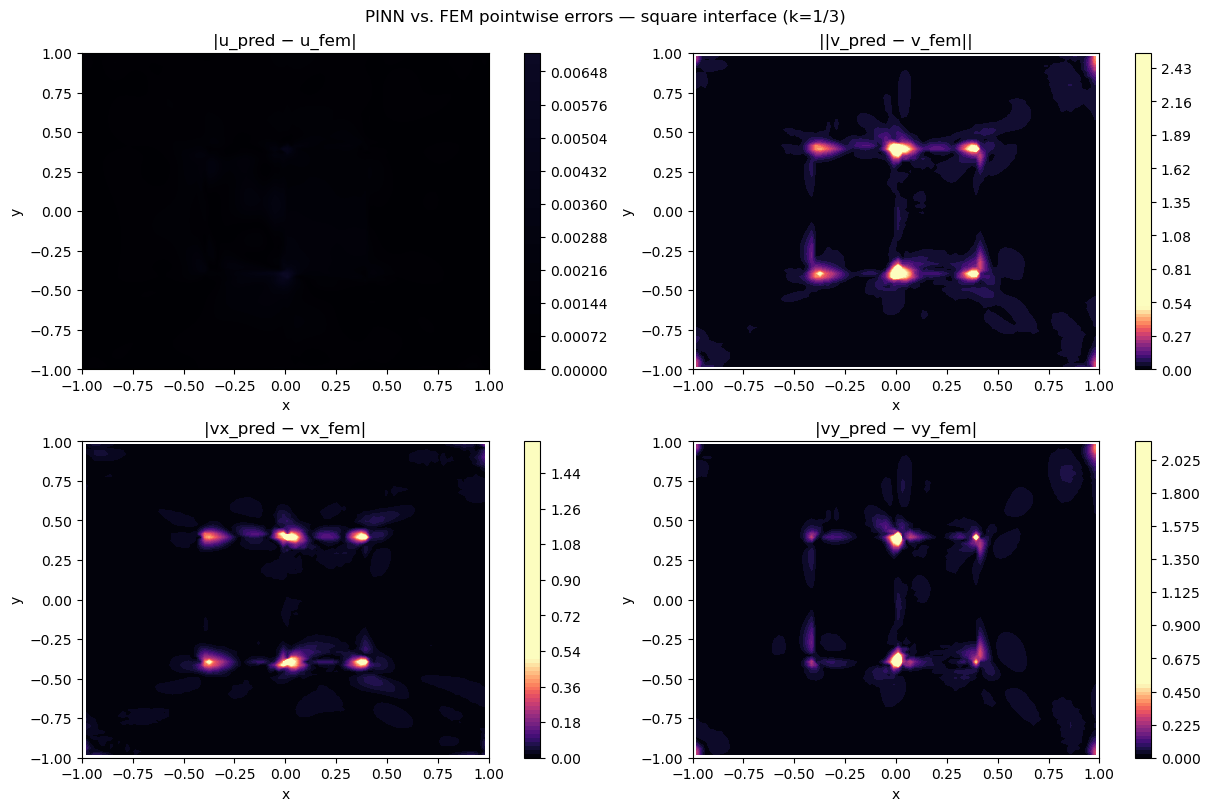

In [39]:
# ── Pointwise L2 error maps (2×2 panel) ───────────────────────────────────

xs = np.unique(xy_np[:, 0])
ys = np.unique(xy_np[:, 1])
nx, ny = len(xs), len(ys)
X = xy_np[:, 0].reshape(nx, ny)
Y = xy_np[:, 1].reshape(nx, ny)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

c1 = axes[0, 0].contourf(X, Y, u_err.cpu().numpy().reshape(nx, ny),
                          levels=100, cmap='magma', vmin=0.0, vmax=0.1)
axes[0, 0].set_title('|u_pred − u_fem|');  axes[0, 0].set_xlabel('x'); axes[0, 0].set_ylabel('y')
fig.colorbar(c1, ax=axes[0, 0])

c2 = axes[0, 1].contourf(X, Y, v_err_mag.cpu().numpy().reshape(nx, ny),
                          levels=100, cmap='magma', vmin=0.0, vmax=0.5)
axes[0, 1].set_title('||v_pred − v_fem||'); axes[0, 1].set_xlabel('x'); axes[0, 1].set_ylabel('y')
fig.colorbar(c2, ax=axes[0, 1])

c3 = axes[1, 0].contourf(X, Y, vx_err.cpu().numpy().reshape(nx, ny),
                          levels=100, cmap='magma', vmin=0.0, vmax=0.5)
axes[1, 0].set_title('|vx_pred − vx_fem|'); axes[1, 0].set_xlabel('x'); axes[1, 0].set_ylabel('y')
fig.colorbar(c3, ax=axes[1, 0])

c4 = axes[1, 1].contourf(X, Y, vy_err.cpu().numpy().reshape(nx, ny),
                          levels=100, cmap='magma', vmin=0.0, vmax=0.5)
axes[1, 1].set_title('|vy_pred − vy_fem|'); axes[1, 1].set_xlabel('x'); axes[1, 1].set_ylabel('y')
fig.colorbar(c4, ax=axes[1, 1])

plt.suptitle('PINN vs. FEM pointwise errors — square interface (k=1/3)')
plt.savefig(f'{SAVE_DIR}/model_errors_exp_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# ── Parameter drift: how much did the weights move during training ─────────

learned = model_combined_exp.state_dict()
initial = model_init_exp.state_dict()
deltas  = [(learned[key].float() - initial[key].float()).abs() for key in learned]
max_drift  = max(d.max().item()  for d in deltas)
mean_drift = sum(d.mean().item() for d in deltas) / len(deltas)

print(f"{'Model':<20}  {'Max |Δparam|':>17}  {'Mean |Δparam|':>18}")
print('-' * 60)
print(f"{'combined_exp':<20}  {max_drift:>17.6e}  {mean_drift:>18.6e}")

Model                      Max |Δparam|       Mean |Δparam|
------------------------------------------------------------
combined_exp               1.295128e+01        2.315940e-01
